# UFC Fight Outcome Predictor -- PyTorch MLP

Predicts which fighter wins a UFC bout using career stats, physical attributes, and rolling momentum.

**Architecture:** 4-layer MLP with BatchNorm + Dropout  
**Design choices:**
- 50% of training rows randomly swap f1 <-> f2 -> balanced classes, no positional shortcut
- Diff features added (f1-f2 per stat) alongside raw columns
- Inference averages both orderings -> probabilities guaranteed to sum to 1.0


## 1. Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import pickle, warnings
warnings.filterwarnings('ignore')

print("PyTorch:", torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

candidate_model_dirs = [Path.cwd() / 'server' / 'models', Path.cwd(), Path.cwd().parent]
MODEL_DIR = next((p for p in candidate_model_dirs if (p / 'data').exists()), Path.cwd())
DATA_DIR = MODEL_DIR / 'data'
FIGHT_RESULTS_PATH = DATA_DIR / 'ufc_fight_results_with_odds.csv'
FIGHTER_STATS_PATH = DATA_DIR / 'ufc-fighters-statistics.csv'


PyTorch: 2.12.0+cu130
Device: cpu


## 2. Data Preparation

In [3]:
def clean_name(name):
    return str(name).lower().strip().replace('.', '').replace("'", "")

def age_at(dob, as_of):
    dob = pd.to_datetime(dob, errors='coerce')
    as_of = pd.to_datetime(as_of, errors='coerce')
    return (as_of - dob).dt.days / 365.25

fight_results = pd.read_csv(FIGHT_RESULTS_PATH)
fighter_stats = pd.read_csv(FIGHTER_STATS_PATH)
fight_results['EVENT'] = fight_results['EVENT'].str.strip()
fight_results['BOUT'] = fight_results['BOUT'].str.strip()
fight_results['fight_date'] = pd.to_datetime(fight_results['fight_date'], errors='coerce')

# Clean stats
fighter_stats = fighter_stats.drop(columns=['nickname'])
num_cols = fighter_stats.select_dtypes('float').columns
fighter_stats[num_cols] = fighter_stats[num_cols].fillna(fighter_stats[num_cols].median())
fighter_stats['date_of_birth'] = pd.to_datetime(fighter_stats['date_of_birth'], errors='coerce')
fighter_stats['stance'] = fighter_stats['stance'].fillna('Unknown')
fighter_stats = pd.get_dummies(fighter_stats, columns=['stance'], prefix='stance', dtype=int)
fighter_stats['name'] = fighter_stats['name'].apply(clean_name)

# Rolling 5-fight win rate (lagged — no data leakage)
fight_results[['fighter_1','fighter_2']] = fight_results['BOUT'].str.split(' vs. ', expand=True)
fight_results['fighter_1'] = fight_results['fighter_1'].apply(clean_name)
fight_results['fighter_2'] = fight_results['fighter_2'].apply(clean_name)

f1 = fight_results[['EVENT','BOUT','fight_date','fighter_1','OUTCOME']].rename(columns={'fighter_1':'name','OUTCOME':'outcome_raw'}).copy()
f2 = fight_results[['EVENT','BOUT','fight_date','fighter_2','OUTCOME']].rename(columns={'fighter_2':'name','OUTCOME':'outcome_raw'}).copy()
f1['win'] = (f1['outcome_raw'].str[0] == 'W').astype(int)
f2['win'] = (f2['outcome_raw'].str[-1] == 'W').astype(int)
all_fights = pd.concat([f1[['EVENT','BOUT','fight_date','name','win']], f2[['EVENT','BOUT','fight_date','name','win']]])
all_fights = all_fights.sort_values(['name','fight_date','EVENT','BOUT'])
all_fights['rolling_win_rate'] = (
    all_fights.groupby('name')['win']
    .transform(lambda x: x.rolling(5, min_periods=1).mean().shift())
)
rolling_fill = all_fights['rolling_win_rate'].mean()
latest_rolling = (
    all_fights.dropna(subset=['rolling_win_rate'])
    .groupby('name', as_index=False).tail(1)[['name','rolling_win_rate']].drop_duplicates('name')
)
fighter_stats = fighter_stats.merge(latest_rolling, on='name', how='left')
fighter_stats['rolling_win_rate'] = fighter_stats['rolling_win_rate'].fillna(rolling_fill)
# Current age is used only by predict_fight; training rows get event-date age below.
fighter_stats['age'] = age_at(fighter_stats['date_of_birth'], pd.Timestamp.today().normalize())
fighter_stats['age'] = fighter_stats['age'].fillna(fighter_stats['age'].median())
fighter_stats_for_training = fighter_stats.drop(columns=['rolling_win_rate'])
fighter_stats = fighter_stats.drop(columns=['date_of_birth'])

f1_rolling = all_fights[['EVENT','BOUT','name','rolling_win_rate']].rename(
    columns={'name': 'fighter_1', 'rolling_win_rate': 'rolling_win_rate_f1'}
)
f2_rolling = all_fights[['EVENT','BOUT','name','rolling_win_rate']].rename(
    columns={'name': 'fighter_2', 'rolling_win_rate': 'rolling_win_rate_f2'}
)

# Build paired dataset (decisive fights only)
decisive = fight_results[fight_results['OUTCOME'].isin(['W/L','L/W'])].copy()
decisive['outcome'] = (decisive['OUTCOME'] == 'W/L').astype(int)  # 1 = fighter_1 won
fight_data = decisive[['EVENT','BOUT','fight_date','fighter_1','fighter_2','outcome']].merge(
    fighter_stats_for_training, left_on='fighter_1', right_on='name', how='inner'
).merge(
    fighter_stats_for_training, left_on='fighter_2', right_on='name', how='inner', suffixes=('_f1','_f2')
).merge(
    f1_rolling, on=['EVENT','BOUT','fighter_1'], how='left'
).merge(
    f2_rolling, on=['EVENT','BOUT','fighter_2'], how='left'
)
fight_data['age_f1'] = age_at(fight_data['date_of_birth_f1'], fight_data['fight_date'])
fight_data['age_f2'] = age_at(fight_data['date_of_birth_f2'], fight_data['fight_date'])
age_fill = pd.concat([fight_data['age_f1'], fight_data['age_f2']]).median()
fight_data[['age_f1','age_f2']] = fight_data[['age_f1','age_f2']].fillna(age_fill)
fight_data[['rolling_win_rate_f1','rolling_win_rate_f2']] = fight_data[['rolling_win_rate_f1','rolling_win_rate_f2']].fillna(rolling_fill)
fight_data['bout_key'] = fight_data['EVENT'].astype(str) + '||' + fight_data['BOUT'].astype(str)
fight_data = fight_data.drop(
    columns=['EVENT','BOUT','fight_date','fighter_1','fighter_2','name_f1','name_f2','date_of_birth_f1','date_of_birth_f2']
).dropna()

# Difference features (relative advantage per stat)
stat_cols = ['wins','losses','draws','height_cm','weight_in_kg','reach_in_cm',
             'significant_strikes_landed_per_minute','significant_striking_accuracy',
             'significant_strikes_absorbed_per_minute','significant_strike_defence',
             'average_takedowns_landed_per_15_minutes','takedown_accuracy','takedown_defense',
             'average_submissions_attempted_per_15_minutes','age','rolling_win_rate']

for col in stat_cols:
    if f'{col}_f1' in fight_data.columns:
        fight_data[f'diff_{col}'] = fight_data[f'{col}_f1'] - fight_data[f'{col}_f2']

print(f"Dataset shape: {fight_data.shape}")
print(f"Outcome distribution: {fight_data['outcome'].value_counts().to_dict()}")


Dataset shape: (8560, 62)
Outcome distribution: {1: 5491, 0: 3069}


## 3. Random Fighter Swap

Fighter 1 is always the higher-ranked fighter in the raw data, so the model would learn a positional shortcut without this step.

We randomly swap f1 ↔ f2 for 50% of rows:
- Raw `_f1`/`_f2` columns are exchanged
- Diff features flip sign (f1−f2 becomes f2−f1)
- Outcome label flips (winner was f1=1, now in position 2=0)

Result: balanced 50/50 classes, no positional bias in training.

In [4]:
f1_cols   = [c for c in fight_data.columns if c.endswith('_f1')]
f2_cols   = [c.replace('_f1', '_f2') for c in f1_cols]
diff_cols = [c for c in fight_data.columns if c.startswith('diff_')]

def swap_fighter_order(X_part, y_part, random_state=42):
    rng = np.random.default_rng(random_state)
    swap_idx = rng.random(len(X_part)) < 0.5
    X_swapped = X_part.copy()
    y_swapped = y_part.copy()
    swap_rows = X_swapped.index[swap_idx]
    X_swapped.loc[swap_rows, f1_cols + f2_cols] = X_swapped.loc[swap_rows, f2_cols + f1_cols].values
    X_swapped.loc[swap_rows, diff_cols] *= -1
    y_swapped.loc[swap_rows] = 1 - y_swapped.loc[swap_rows]
    return X_swapped, y_swapped, int(swap_idx.sum())

def grouped_split(X_part, y_part, groups_part, test_size, random_state):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    return next(splitter.split(X_part, y_part, groups_part))


## 4. Train/Test Split & Scaling

In [5]:
groups = fight_data['bout_key']
X = fight_data.drop(columns=['outcome','bout_key'])
y = fight_data['outcome']

train_val_idx, test_idx = grouped_split(X, y, groups, test_size=0.2, random_state=42)
X_train_val, X_test = X.iloc[train_val_idx], X.iloc[test_idx]
y_train_val, y_test = y.iloc[train_val_idx], y.iloc[test_idx]
groups_train_val = groups.iloc[train_val_idx]
assert set(groups_train_val).isdisjoint(set(groups.iloc[test_idx]))

train_idx, val_idx = grouped_split(X_train_val, y_train_val, groups_train_val, test_size=0.2, random_state=43)
X_train, X_val = X_train_val.iloc[train_idx], X_train_val.iloc[val_idx]
y_train, y_val = y_train_val.iloc[train_idx], y_train_val.iloc[val_idx]
assert set(groups_train_val.iloc[train_idx]).isdisjoint(set(groups_train_val.iloc[val_idx]))

X_train, y_train, swapped_train = swap_fighter_order(X_train, y_train, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Rows swapped in train: {swapped_train} / {len(X_train)}")
print(f"Train outcome distribution (after swap): {y_train.value_counts().to_dict()}")
print(f"Train: {X_train_s.shape} | Val: {X_val_s.shape} | Test: {X_test_s.shape}")
print(f"Total features: {X_train_s.shape[1]}")


Rows swapped in train: 2799 / 5480
Train outcome distribution (after swap): {0: 2839, 1: 2641}
Train: (5480, 60) | Val: (1370, 60) | Test: (1710, 60)
Total features: 60


## 5. Model Architecture

In [6]:
class FightNet(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

model = FightNet(X_train_s.shape[1]).to(device)
print(model)
print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")

FightNet(
  (net): Sequential(
    (0): Linear(in_features=60, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)

Parameters: 57,601


## 6. Training

In [7]:
X_tr = torch.tensor(X_train_s, dtype=torch.float32).to(device)
y_tr = torch.tensor(y_train.values, dtype=torch.float32).to(device)
X_va = torch.tensor(X_val_s, dtype=torch.float32).to(device)
y_va = torch.tensor(y_val.values, dtype=torch.float32).to(device)
X_te = torch.tensor(X_test_s,  dtype=torch.float32).to(device)
y_te = torch.tensor(y_test.values,  dtype=torch.float32).to(device)

train_dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)

# Dataset is ~50/50 after swap — no pos_weight needed
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80)

EPOCHS = 80
train_losses, val_losses, val_accs = [], [], []

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for xb, yb in train_dl:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    scheduler.step()

    model.eval()
    with torch.no_grad():
        val_logits = model(X_va)
        val_loss = criterion(val_logits, y_va).item()
        val_acc  = ((torch.sigmoid(val_logits) > 0.5).float() == y_va).float().mean().item()

    train_losses.append(np.mean(batch_losses))
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | train={train_losses[-1]:.4f} | val={val_loss:.4f} | acc={val_acc:.4f}")

print("\nDone!")


Epoch  10 | train=0.5094 | val=0.5628 | acc=0.7073
Epoch  20 | train=0.4615 | val=0.5762 | acc=0.7175
Epoch  30 | train=0.4160 | val=0.6117 | acc=0.7051
Epoch  40 | train=0.3829 | val=0.6068 | acc=0.7015
Epoch  50 | train=0.3460 | val=0.6811 | acc=0.6839
Epoch  60 | train=0.3198 | val=0.7078 | acc=0.6971
Epoch  70 | train=0.3091 | val=0.7334 | acc=0.6832
Epoch  80 | train=0.3099 | val=0.7263 | acc=0.6912

Done!


## 7. Training Curves

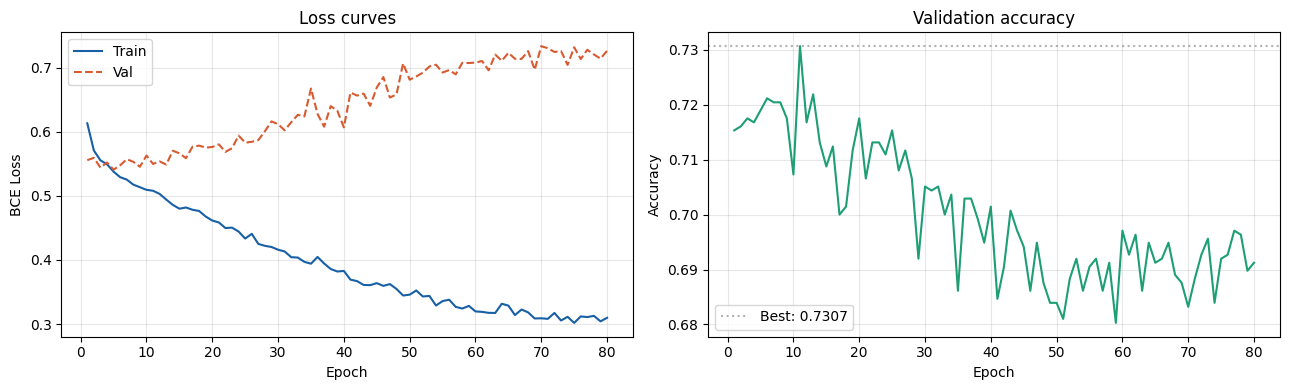

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
e = range(1, EPOCHS + 1)

ax1.plot(e, train_losses, label='Train', color='#185FA5')
ax1.plot(e, val_losses,   label='Val',   color='#D85A30', linestyle='--')
ax1.set(xlabel='Epoch', ylabel='BCE Loss', title='Loss curves')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(e, val_accs, color='#1D9E75')
ax2.axhline(max(val_accs), color='gray', linestyle=':', alpha=0.6, label=f'Best: {max(val_accs):.4f}')
ax2.set(xlabel='Epoch', ylabel='Accuracy', title='Validation accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluation

In [9]:
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(X_te)).cpu().numpy()
preds = (probs > 0.5).astype(int)

print(f"Test Accuracy : {accuracy_score(y_test, preds):.4f}")
print(f"Test AUC      : {roc_auc_score(y_test, probs):.4f}")
print()
print(classification_report(y_test, preds, target_names=['Fighter 2 wins', 'Fighter 1 wins']))

Test Accuracy : 0.6754
Test AUC      : 0.7426

                precision    recall  f1-score   support

Fighter 2 wins       0.55      0.68      0.61       638
Fighter 1 wins       0.78      0.67      0.72      1072

      accuracy                           0.68      1710
     macro avg       0.67      0.68      0.67      1710
  weighted avg       0.70      0.68      0.68      1710



## 9. Predict a Fight

Inference averages both orderings (A vs B and B vs A) so probabilities are guaranteed to sum to 1.0 regardless of which fighter you pass first.


In [10]:
fs_num_cols = [c for c in fighter_stats.columns if c != 'name']

def _make_tensor(r1, r2):
    """Build a scaled input tensor for one ordering of two fighters."""
    row = {}
    for c in fs_num_cols:
        row[f'{c}_f1'] = r1[c]
        row[f'{c}_f2'] = r2[c]
    for col in stat_cols:
        if f'{col}_f1' in row:
            row[f'diff_{col}'] = row[f'{col}_f1'] - row[f'{col}_f2']
    df = pd.DataFrame([row])[X.columns]
    return torch.tensor(scaler.transform(df), dtype=torch.float32).to(device)

def predict_fight(fighter1_name: str, fighter2_name: str, verbose: bool = True):
    """
    Predict the winner between two fighters by name.
    Averages P(f1 wins | ordering AB) and P(f1 wins | ordering BA)
    so the result is symmetric regardless of argument order.
    """
    f1n, f2n = clean_name(fighter1_name), clean_name(fighter2_name)
    if f1n not in fighter_stats['name'].values:
        print(f"'{fighter1_name}' not found."); return None
    if f2n not in fighter_stats['name'].values:
        print(f"'{fighter2_name}' not found."); return None

    r1 = fighter_stats[fighter_stats['name'] == f1n].iloc[0]
    r2 = fighter_stats[fighter_stats['name'] == f2n].iloc[0]

    model.eval()
    with torch.no_grad():
        p_ab = torch.sigmoid(model(_make_tensor(r1, r2))).item()
        p_ba = torch.sigmoid(model(_make_tensor(r2, r1))).item()

    # Average both orderings — sum guaranteed to be 1.0
    prob_f1 = (p_ab + (1 - p_ba)) / 2

    winner   = fighter1_name if prob_f1 > 0.5 else fighter2_name
    win_prob = prob_f1 if prob_f1 > 0.5 else 1 - prob_f1

    if verbose:
        print(f"{'='*47}")
        print(f"  {fighter1_name}  vs.  {fighter2_name}")
        print(f"{'='*47}")
        print(f"  Predicted winner : {winner}")
        print(f"  Confidence       : {win_prob:.1%}")
        print(f"  P({fighter1_name} wins) : {prob_f1:.1%}")
        print(f"  P({fighter2_name} wins) : {1-prob_f1:.1%}")

    return winner, win_prob

predict_fight("Jon Jones", "Stipe Miocic"); print()
predict_fight("Islam Makhachev", "Charles Oliveira"); print()
predict_fight("Alex Pereira", "Magomed Ankalaev")


  Jon Jones  vs.  Stipe Miocic
  Predicted winner : Jon Jones
  Confidence       : 99.7%
  P(Jon Jones wins) : 99.7%
  P(Stipe Miocic wins) : 0.3%

  Islam Makhachev  vs.  Charles Oliveira
  Predicted winner : Islam Makhachev
  Confidence       : 99.7%
  P(Islam Makhachev wins) : 99.7%
  P(Charles Oliveira wins) : 0.3%

  Alex Pereira  vs.  Magomed Ankalaev
  Predicted winner : Magomed Ankalaev
  Confidence       : 89.7%
  P(Alex Pereira wins) : 10.3%
  P(Magomed Ankalaev wins) : 89.7%


('Magomed Ankalaev', 0.8969241939485073)

## 10. Symmetry Check

Confirm that `predict_fight(A, B)` and `predict_fight(B, A)` give consistent, complementary probabilities.


In [11]:
def symmetry_check(a, b):
    _, _ = predict_fight(a, b, verbose=False), predict_fight(b, a, verbose=False)
    r1 = fighter_stats[fighter_stats['name'] == clean_name(a)].iloc[0]
    r2 = fighter_stats[fighter_stats['name'] == clean_name(b)].iloc[0]
    model.eval()
    with torch.no_grad():
        p_ab = torch.sigmoid(model(_make_tensor(r1, r2))).item()
        p_ba = torch.sigmoid(model(_make_tensor(r2, r1))).item()
    prob_a_as_f1 = (p_ab + (1 - p_ba)) / 2
    prob_a_as_f2 = ((1 - p_ab) + p_ba) / 2  # same fight, A passed second
    print(f"{a} vs {b}")
    print(f"  P({a} wins, A first) : {prob_a_as_f1:.3f}")
    print(f"  P({a} wins, A second): {prob_a_as_f2:.3f}  ← should match")
    print(f"  Sum: {prob_a_as_f1 + (1 - prob_a_as_f1):.3f}  ✓")
    print()

symmetry_check("Jon Jones", "Stipe Miocic")
symmetry_check("Islam Makhachev", "Charles Oliveira")
symmetry_check("Alex Pereira", "Magomed Ankalaev")


Jon Jones vs Stipe Miocic
  P(Jon Jones wins, A first) : 0.997
  P(Jon Jones wins, A second): 0.003  ← should match
  Sum: 1.000  ✓

Islam Makhachev vs Charles Oliveira
  P(Islam Makhachev wins, A first) : 0.997
  P(Islam Makhachev wins, A second): 0.003  ← should match
  Sum: 1.000  ✓

Alex Pereira vs Magomed Ankalaev
  P(Alex Pereira wins, A first) : 0.103
  P(Alex Pereira wins, A second): 0.897  ← should match
  Sum: 1.000  ✓



In [12]:
predict_fight("Israel Adesanya", "Kamaru Usman")

  Israel Adesanya  vs.  Kamaru Usman
  Predicted winner : Israel Adesanya
  Confidence       : 92.1%
  P(Israel Adesanya wins) : 92.1%
  P(Kamaru Usman wins) : 7.9%


('Israel Adesanya', 0.921397477388382)

## 11. Save & Load

In [13]:
torch.save(model.state_dict(), 'fight_model.pt')
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Saved fight_model.pt and scaler.pkl")

# Reload
loaded = FightNet(X_train_s.shape[1]).to(device)
loaded.load_state_dict(torch.load('fight_model.pt', map_location=device))
loaded.eval()
print("Reloaded successfully.")

Saved fight_model.pt and scaler.pkl
Reloaded successfully.
